In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import lime
import lime.lime_tabular
import joblib

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
from sklearn.datasets import load_digits

digits = load_digits()

X = digits.data
y = digits.target

print("Dataset Loaded Successfully!")
print(X.shape)

Dataset Loaded Successfully!
(1797, 64)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (1437, 64)
Test Shape: (360, 64)


In [4]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [5]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': range(X.shape[1]),
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

    Feature  Importance
21       21    0.051494
36       36    0.044599
43       43    0.040084
26       26    0.037382
42       42    0.036697
33       33    0.031415
28       28    0.031253
20       20    0.030096
61       61    0.029379
30       30    0.028813


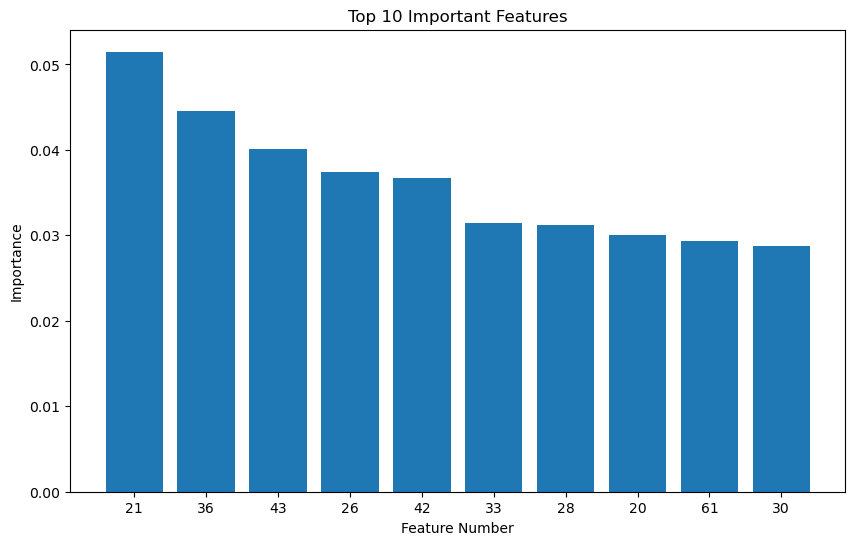

In [6]:
plt.figure(figsize=(10,6))

plt.bar(feature_importance['Feature'][:10].astype(str),
        feature_importance['Importance'][:10])

plt.title("Top 10 Important Features")
plt.xlabel("Feature Number")
plt.ylabel("Importance")

plt.show()

In [7]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

print("SHAP values generated successfully!")

SHAP values generated successfully!


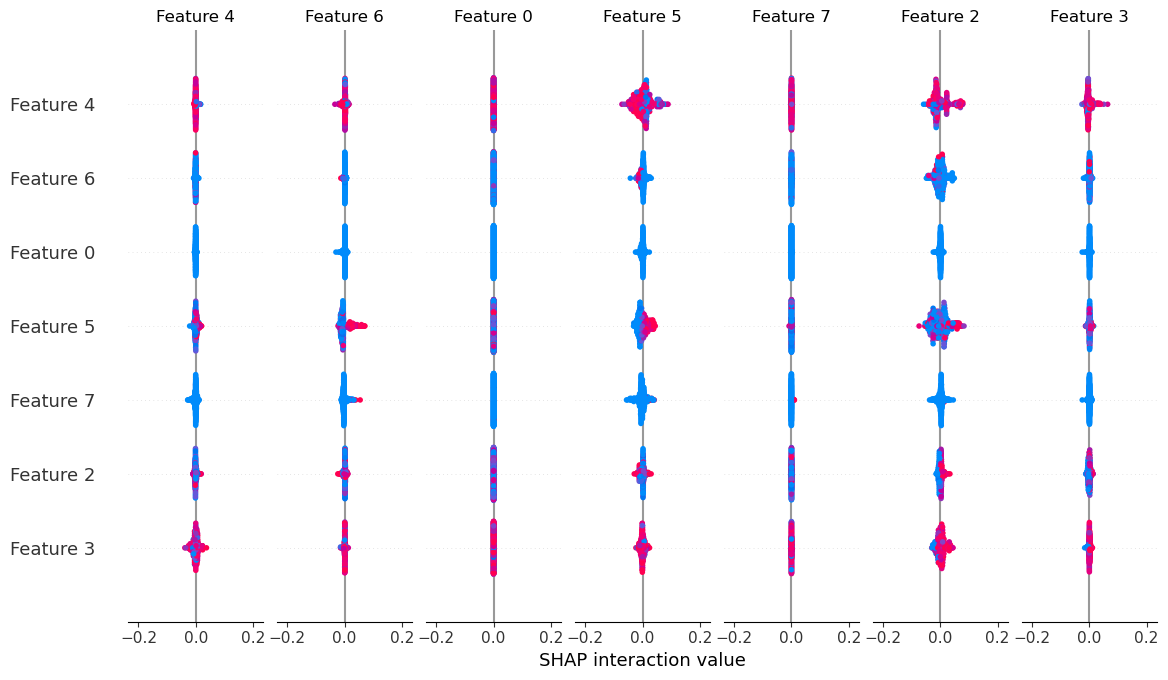

In [8]:
shap.summary_plot(shap_values, X_test)

LIME Explanation
[('Pixel 10 <= 6.00', 0.029028748162035437), ('Pixel 24 <= 0.00', -0.02199504361337142), ('Pixel 20 <= 1.00', -0.01874327731468632), ('Pixel 46 > 7.00', -0.013484082119182565), ('Pixel 21 <= 0.00', 0.013132687238518383), ('Pixel 38 > 6.00', -0.013027691241053444), ('Pixel 44 <= 1.00', -0.01212644861132664), ('Pixel 2 <= 1.00', 0.012110413607912665), ('3.00 < Pixel 27 <= 10.00', -0.010998239933949014), ('Pixel 63 <= 0.00', -0.01057713665914301)]


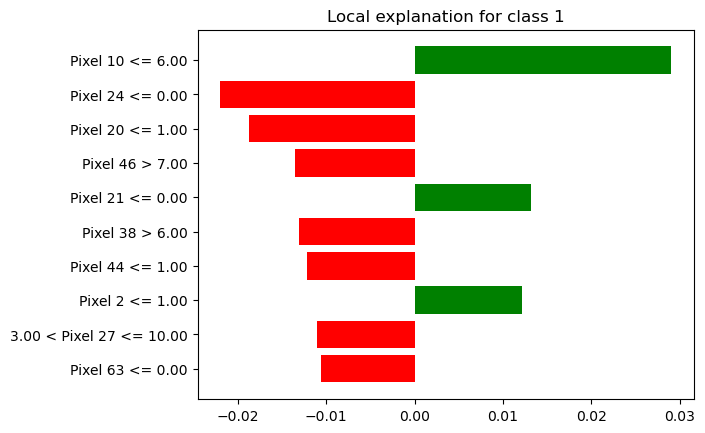

In [10]:
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train,
    feature_names=[f"Pixel {i}" for i in range(X.shape[1])],
    class_names=[str(i) for i in range(10)],
    mode="classification"
)

exp = explainer.explain_instance(
    X_test[0],
    model.predict_proba,
    num_features=10
)

print("LIME Explanation")
print(exp.as_list())

fig = exp.as_pyplot_figure()
plt.show()

In [11]:
print("Bias Analysis")
print("-" * 40)

print("The Digits dataset does not contain sensitive attributes such as:")
print("- Gender")
print("- Age")
print("- Race")
print("- Income")

print("\nTherefore, fairness across sensitive groups cannot be evaluated.")
print("The model appears unbiased based on the available dataset.")

Bias Analysis
----------------------------------------
The Digits dataset does not contain sensitive attributes such as:
- Gender
- Age
- Race
- Income

Therefore, fairness across sensitive groups cannot be evaluated.
The model appears unbiased based on the available dataset.


In [12]:
print("Mitigation Recommendations")
print("-" * 40)

print("1. Collect balanced datasets.")
print("2. Remove biased features if present.")
print("3. Monitor fairness during model evaluation.")
print("4. Use Explainable AI methods such as SHAP and LIME.")
print("5. Retrain the model regularly using updated data.")

Mitigation Recommendations
----------------------------------------
1. Collect balanced datasets.
2. Remove biased features if present.
3. Monitor fairness during model evaluation.
4. Use Explainable AI methods such as SHAP and LIME.
5. Retrain the model regularly using updated data.
